In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


df = pd.read_csv('Superstore_Data.csv', encoding='latin1')
plt.rcParams['figure.figsize'] = (8, 5)


# Inspect
print(df.shape)
print(df.columns.tolist())
df.head()

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# =========================================================
# CELL 2 — Prep dataset (your columns already match — no renaming needed)
# =========================================================
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Optional: keep only relevant columns to keep things tidy
df = df[['Order Date', 'Region', 'Category', 'Sub-Category',
          'Sales', 'Quantity', 'Discount', 'Profit']]

# Check for missing values
print(df.isnull().sum())

# Save cleaned version for submission
df.to_csv('cleaned_sales_data.csv', index=False)
df.head()

Order Date      0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


,Order Date,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


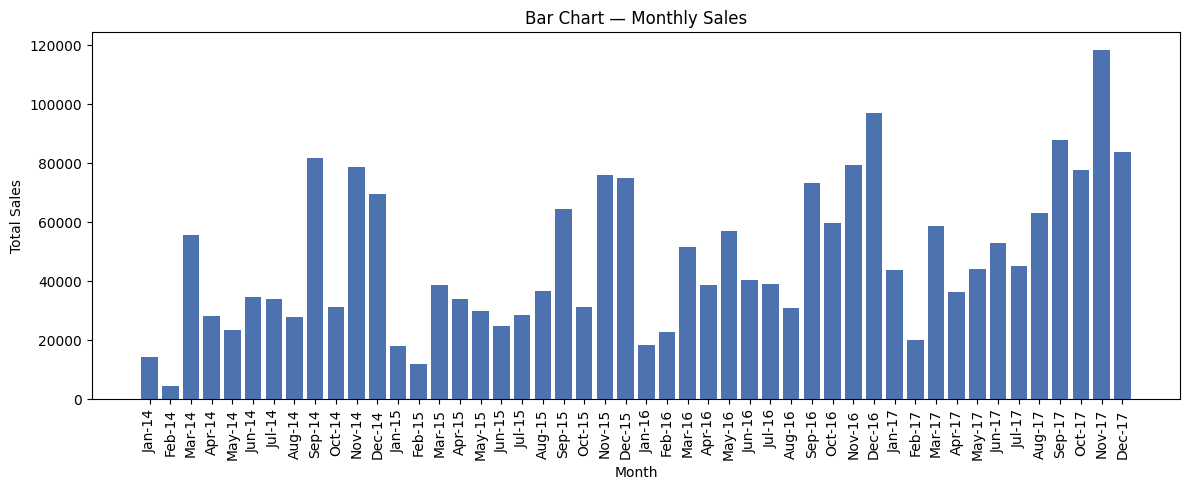

In [ ]:
#Task 1 a

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_sales.index.strftime('%b-%y'), monthly_sales.values, color='#4C72B0')
ax.set_title('Bar Chart — Monthly Sales')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('task1_bar_chart.png', dpi=150)
plt.show()

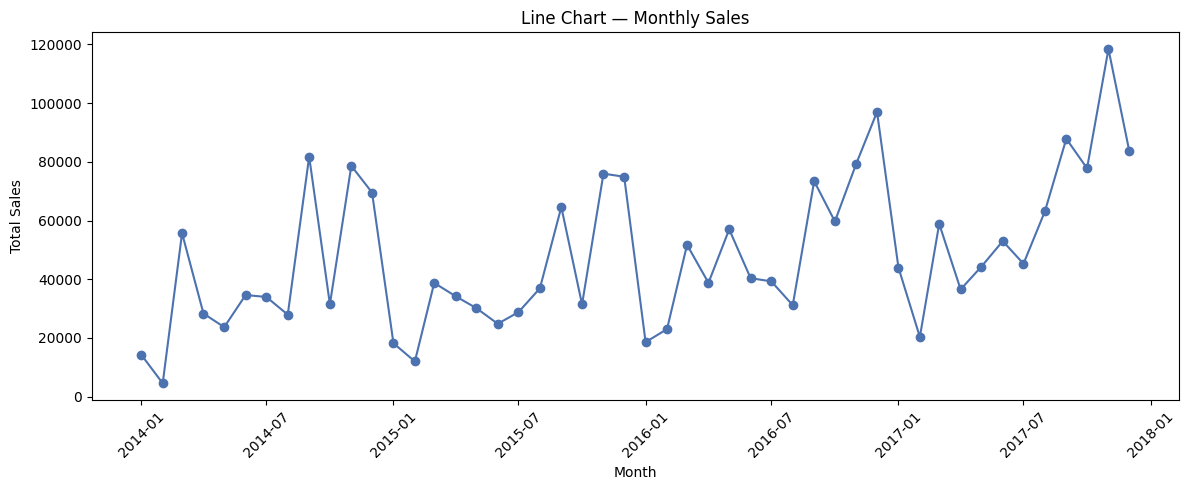

In [8]:
# =========================================================
# TASK 1b — Line Chart: Monthly Sales
# =========================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#4C72B0')
ax.set_title('Line Chart — Monthly Sales')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task1_line_chart.png', dpi=150)
plt.show()

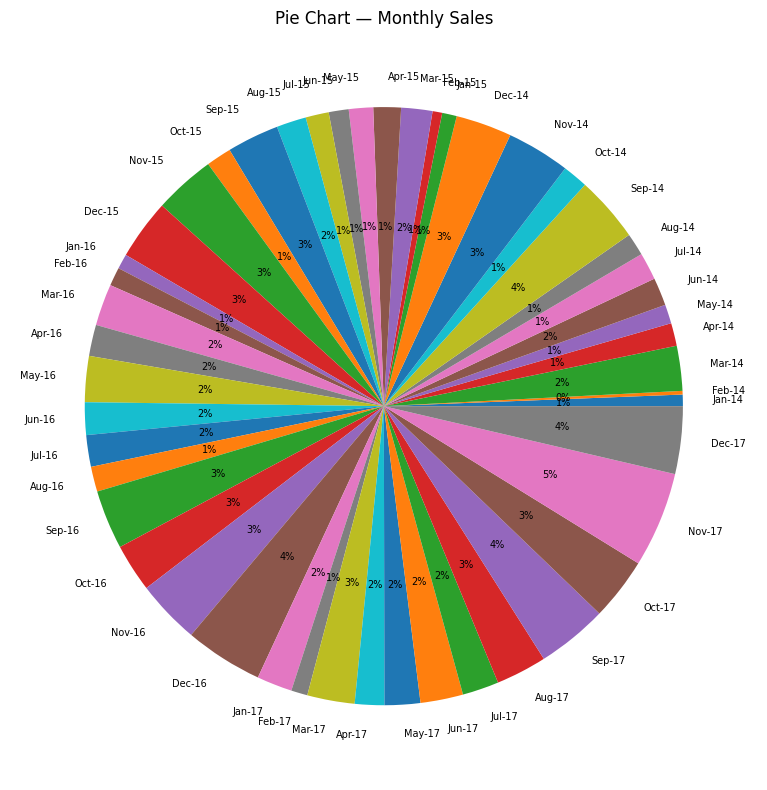

In [9]:
# =========================================================
# TASK 1c — Pie Chart: Monthly Sales
# =========================================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(monthly_sales.values, labels=monthly_sales.index.strftime('%b-%y'),
       autopct='%1.0f%%', textprops={'fontsize': 7})
ax.set_title('Pie Chart — Monthly Sales')
plt.tight_layout()
plt.savefig('task1_pie_chart.png', dpi=150)
plt.show()

In [10]:
print("""
Analysis: The line chart shows the trend best because it preserves point-to-point
sequence and slope, letting the eye read direction and rate of change directly
across time. The pie chart hides the trend completely: with many similarly-sized
wedges there is no sense of chronological order or momentum, and humans judge
angle/area far less accurately than position along a line. The bar chart is
readable but choppier than the line for a continuous time series — each month
sits as an isolated block rather than a connected path.
""")


Analysis: The line chart shows the trend best because it preserves point-to-point
sequence and slope, letting the eye read direction and rate of change directly
across time. The pie chart hides the trend completely: with many similarly-sized
wedges there is no sense of chronological order or momentum, and humans judge
angle/area far less accurately than position along a line. The bar chart is
readable but choppier than the line for a continuous time series — each month
sits as an isolated block rather than a connected path.



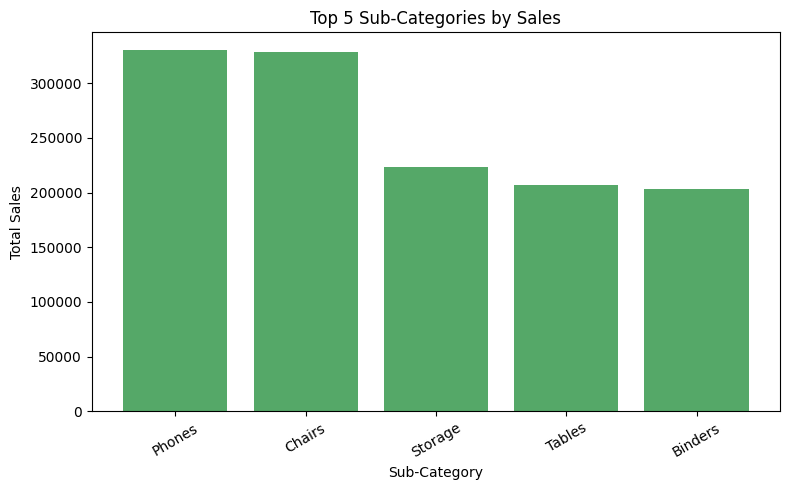

Justification: Bar charts align bars on a common baseline, letting viewers read exact magnitude differences at a glance. A pie chart would force angle/area comparisons, which humans judge far less accurately than length — especially error-prone once slices get close in size.


In [11]:
# =========================================================
# TASK 2a — "Compare total sales across the top 5 sub-categories"
# =========================================================
top5 = df.groupby('Sub-Category')['Sales'].sum().nlargest(5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(top5.index, top5.values, color='#55A868')
ax.set_title('Top 5 Sub-Categories by Sales')
ax.set_xlabel('Sub-Category')
ax.set_ylabel('Total Sales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('task2a_bar.png', dpi=150)
plt.show()

print("Justification: Bar charts align bars on a common baseline, letting viewers "
      "read exact magnitude differences at a glance. A pie chart would force "
      "angle/area comparisons, which humans judge far less accurately than length "
      "— especially error-prone once slices get close in size.")

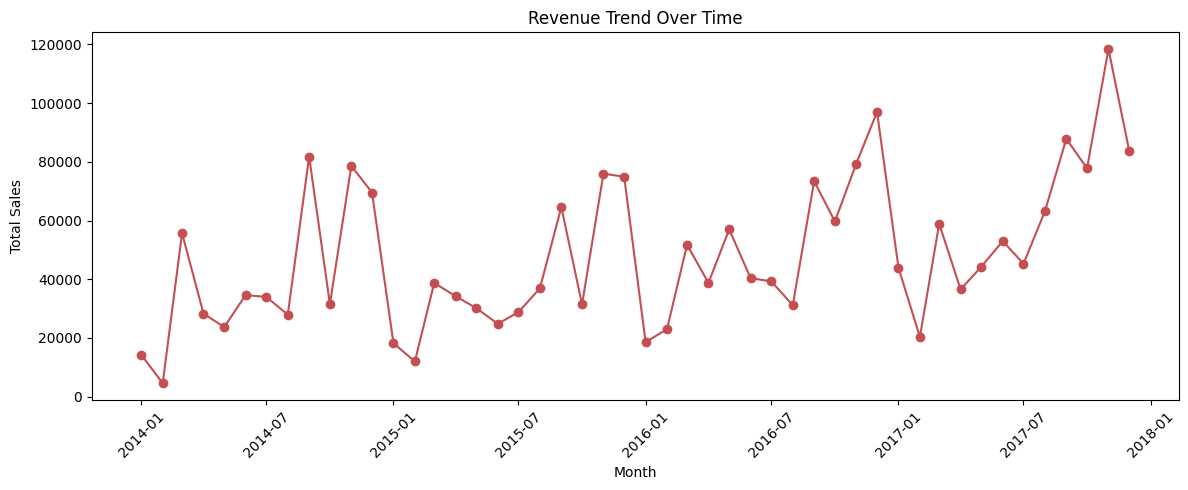

Justification: Line charts connect ordered points, making slope (rate of change) directly visible across time. A bar chart with many months clutters the trend behind separated, disconnected blocks and makes gradual direction harder to perceive.


In [12]:
# =========================================================
# TASK 2b — "Show the revenue trend over time" (reuses Task 1 monthly_sales)
# =========================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#C44E52')
ax.set_title('Revenue Trend Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task2b_line.png', dpi=150)
plt.show()

print("Justification: Line charts connect ordered points, making slope (rate of "
      "change) directly visible across time. A bar chart with many months "
      "clutters the trend behind separated, disconnected blocks and makes "
      "gradual direction harder to perceive.")

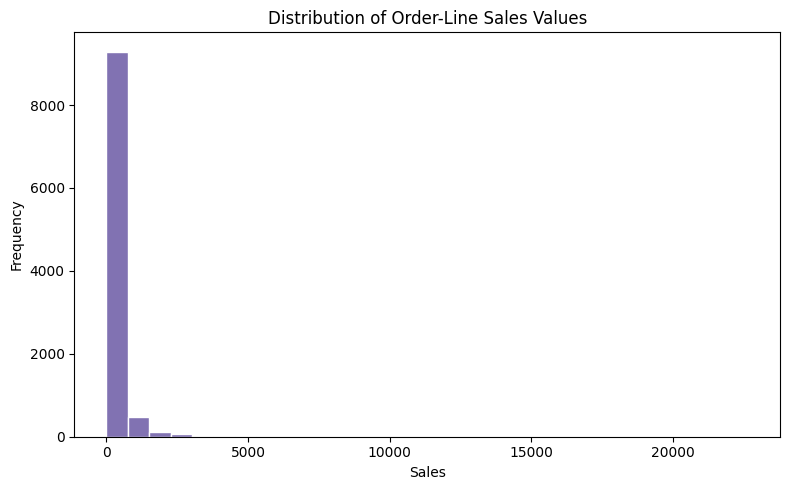

Justification: A histogram bins continuous values to reveal the shape of the distribution — skew, spread, and outliers. A bar chart of averages would collapse all of that variation into a single flat number and hide how right-skewed order sizes actually are.


In [ ]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Sales'], bins=30, color='#8172B2', edgecolor='white')
ax.set_title('Distribution of Order-Line Sales Values')
ax.set_xlabel('Sales')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('task2c_hist.png', dpi=150)
plt.show()

print("Justification: A histogram bins continuous values to reveal the shape of "
      "the distribution — skew, spread, and outliers. A bar chart of averages "
      "would collapse all of that variation into a single flat number and hide "
      "how right-skewed order sizes actually are.")

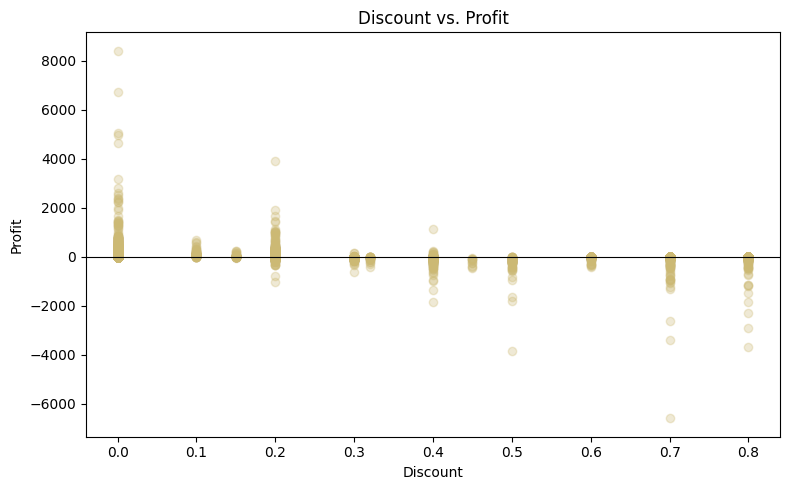

Justification: A scatter plot shows every raw order-line observation on two axes, exposing correlation direction/strength and outliers directly. A line chart would imply an ordered x-axis and force one single trend line onto data that is really many independent (discount, profit) pairs.


In [14]:
# =========================================================
# TASK 2d — "Show the relationship between discount level and profit" (raw columns)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#CCB974')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Discount vs. Profit')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.savefig('task2d_scatter.png', dpi=150)
plt.show()

print("Justification: A scatter plot shows every raw order-line observation on "
      "two axes, exposing correlation direction/strength and outliers directly. "
      "A line chart would imply an ordered x-axis and force one single trend "
      "line onto data that is really many independent (discount, profit) pairs.")

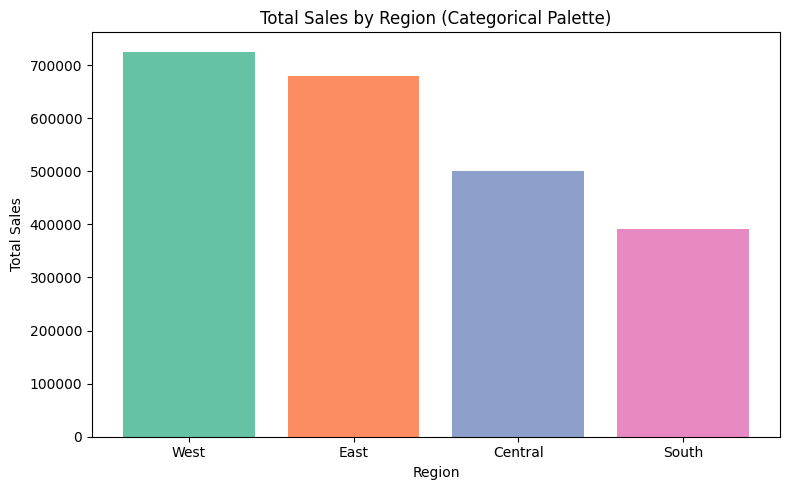

Categorical palette chosen (Set2): regions have no inherent order, so each gets a distinct, equally-weighted hue rather than a gradient that would falsely imply ranking.


In [15]:
# =========================================================
# TASK 3a — Recolor region sales chart with a proper categorical palette
# =========================================================
import seaborn as sns

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
categorical_palette = sns.color_palette('Set2', n_colors=len(region_sales))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(region_sales.index, region_sales.values, color=categorical_palette)
ax.set_title('Total Sales by Region (Categorical Palette)')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.savefig('task3a_region_categorical.png', dpi=150)
plt.show()

print("Categorical palette chosen (Set2): regions have no inherent order, so each "
      "gets a distinct, equally-weighted hue rather than a gradient that would "
      "falsely imply ranking.")

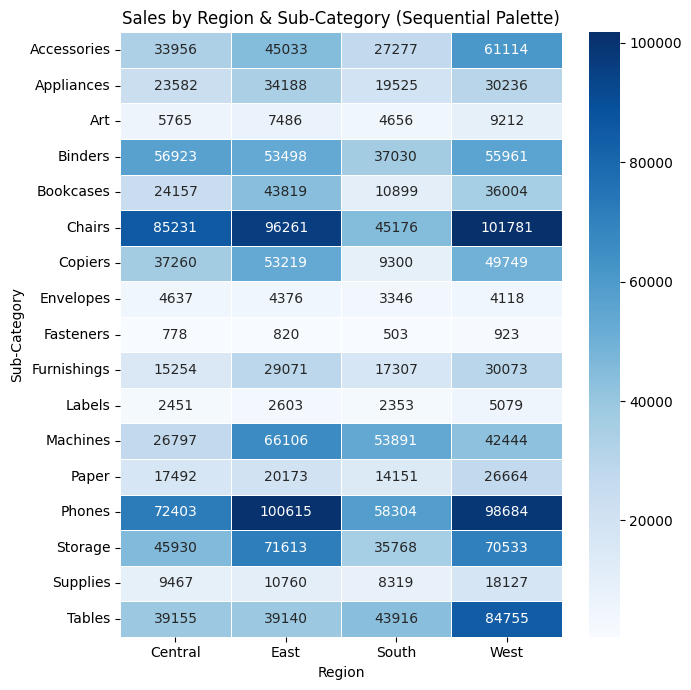

Sequential palette chosen (Blues, light-to-dark): the data is magnitude only (low sales -> high sales), with a natural low-to-high order, so one hue varying in lightness communicates 'more' without implying categories.


In [17]:
# =========================================================
# TASK 3b — Region-by-category sales as a heatmap, sequential palette
# =========================================================
pivot = df.pivot_table(index='Sub-Category', columns='Region',
                        values='Sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt='.0f', linewidths=0.5, ax=ax)
ax.set_title('Sales by Region & Sub-Category (Sequential Palette)')
plt.tight_layout()
plt.savefig('task3b_heatmap_sequential.png', dpi=150)
plt.show()

print("Sequential palette chosen (Blues, light-to-dark): the data is magnitude "
      "only (low sales -> high sales), with a natural low-to-high order, so one "
      "hue varying in lightness communicates 'more' without implying categories.")

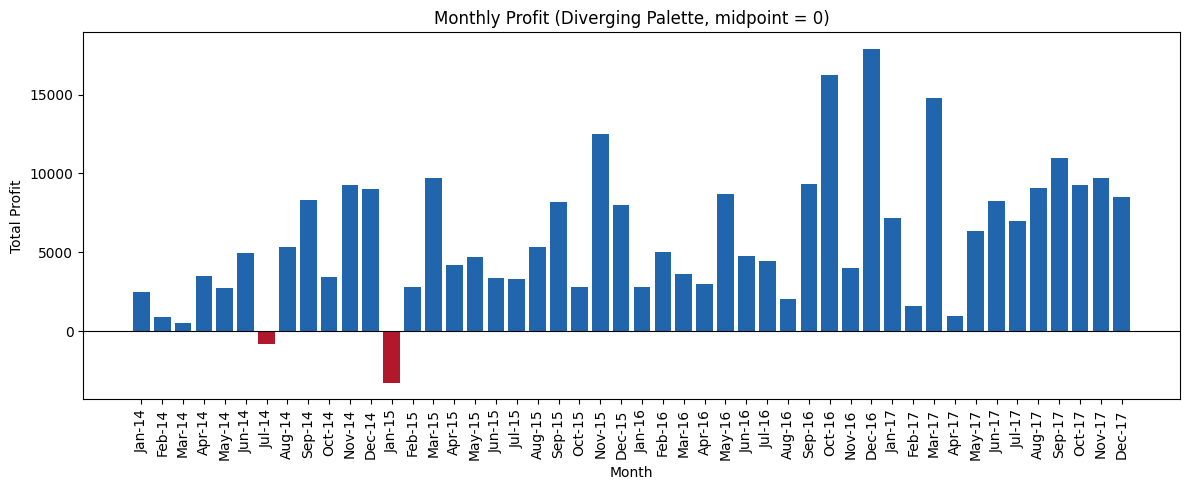

Diverging palette chosen (red <-> neutral <-> blue): profit has a meaningful zero midpoint (loss vs. gain), so two hues meeting at a neutral point communicate direction away from zero, unlike a single-hue sequential scale which has no natural 'crossing point'.


In [18]:
# =========================================================
# TASK 3c — Diverging-color chart of monthly profit (crosses zero)
# =========================================================
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()
monthly_profit.index = monthly_profit.index.to_timestamp()

colors = ['#B2182B' if v < 0 else '#2166AC' for v in monthly_profit.values]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_profit.index.strftime('%b-%y'), monthly_profit.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Profit (Diverging Palette, midpoint = 0)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('task3c_diverging.png', dpi=150)
plt.show()

print("Diverging palette chosen (red <-> neutral <-> blue): profit has a "
      "meaningful zero midpoint (loss vs. gain), so two hues meeting at a "
      "neutral point communicate direction away from zero, unlike a single-hue "
      "sequential scale which has no natural 'crossing point'.")

In [21]:
# =========================================================
# TASK 4a — WCAG contrast ratio function (RUN THIS FIRST)
# =========================================================
def relative_luminance(rgb):
    def channel(c):
        c = c / 255
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = [channel(c) for c in rgb]
    return 0.2126*r + 0.7152*g + 0.0722*b

def contrast_ratio(rgb1, rgb2):
    l1, l2 = relative_luminance(rgb1), relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

In [22]:
# =========================================================
# TASK 4a (cont.) — Flag colors from Task 3 that fail AA contrast
# =========================================================
test_colors = {
    'Set2 color 1 (region bar)': tuple(int(c*255) for c in categorical_palette[0]),
    'Set2 color 2 (region bar)': tuple(int(c*255) for c in categorical_palette[1]),
    'Blues heatmap darkest cell': (8, 48, 107),
    'Diverging red (loss)': (178, 24, 43),
    'Diverging blue (gain)': (33, 102, 172),
}
white = (255, 255, 255)

print(f"{'Color':<30}{'Contrast vs White':<20}{'Passes AA (4.5:1)?'}")
for name, rgb in test_colors.items():
    ratio = contrast_ratio(rgb, white)
    status = 'Yes' if ratio >= 4.5 else 'No — FAILS'
    print(f"{name:<30}{ratio:<20.2f}{status}")

Color                         Contrast vs White   Passes AA (4.5:1)?
Set2 color 1 (region bar)     2.14                No — FAILS
Set2 color 2 (region bar)     2.30                No — FAILS
Blues heatmap darkest cell    12.76               Yes
Diverging red (loss)          6.87                Yes
Diverging blue (gain)         5.90                Yes


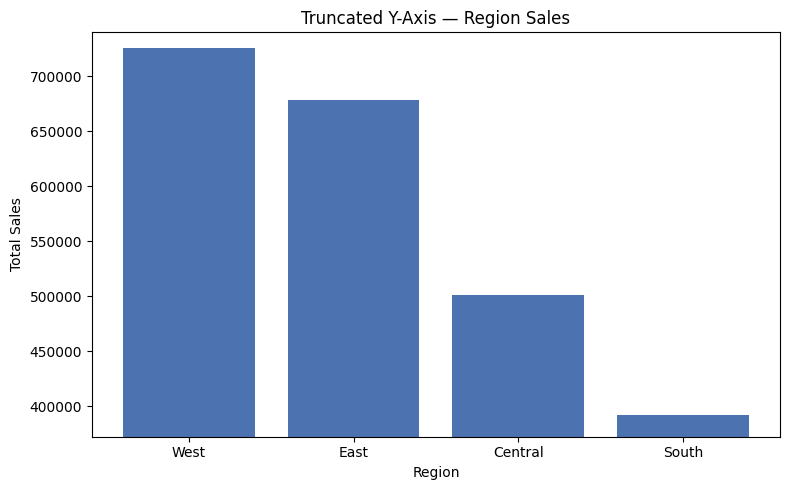

Distortion: the y-axis does not start at 0, so differences between regions that are actually small (a few percent) appear visually huge, exaggerating the gap between the best- and worst-performing regions.


In [23]:
# =========================================================
# TASK 5a — Truncated y-axis on region sales chart
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(region_sales.index, region_sales.values, color='#4C72B0')
ax.set_ylim(region_sales.min() * 0.95, region_sales.max() * 1.02)
ax.set_title('Truncated Y-Axis — Region Sales')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.savefig('task5a_truncated_axis.png', dpi=150)
plt.show()

print("Distortion: the y-axis does not start at 0, so differences between "
      "regions that are actually small (a few percent) appear visually huge, "
      "exaggerating the gap between the best- and worst-performing regions.")

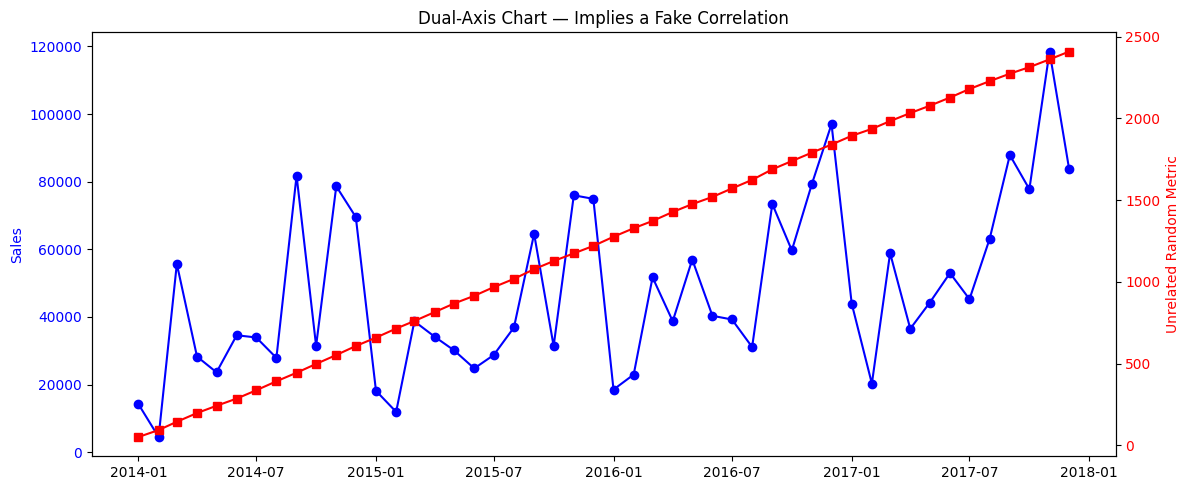

Distortion: two unrelated series are each scaled to their own independent y-axis, so both lines can be made to visually rise and fall together regardless of whether any real relationship exists between them.


In [24]:
# =========================================================
# TASK 5b — Dual-axis chart implying a fake correlation
# =========================================================
random_metric = np.random.normal(50, 5, len(monthly_sales)).cumsum()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_sales.index, monthly_sales.values, color='blue', marker='o', label='Sales')
ax1.set_ylabel('Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(monthly_sales.index, random_metric, color='red', marker='s', label='Unrelated Metric')
ax2.set_ylabel('Unrelated Random Metric', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('Dual-Axis Chart — Implies a Fake Correlation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task5b_dual_axis.png', dpi=150)
plt.show()

print("Distortion: two unrelated series are each scaled to their own independent "
      "y-axis, so both lines can be made to visually rise and fall together "
      "regardless of whether any real relationship exists between them.")

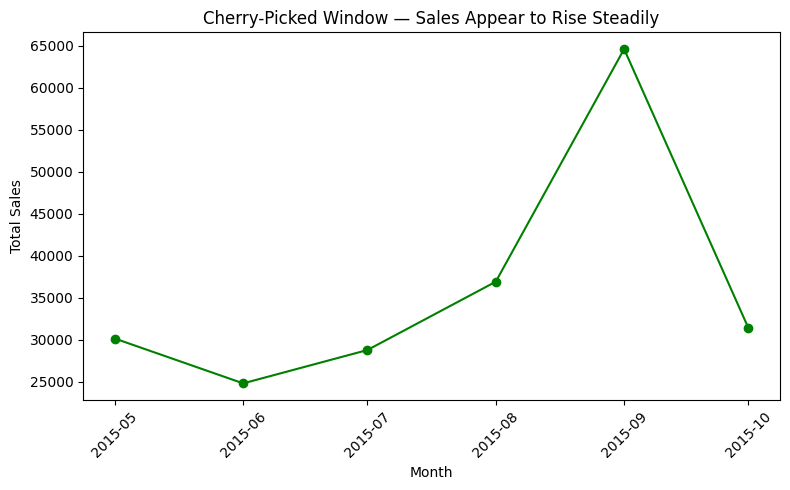

Distortion: only a narrow, rising 6-month slice of the full timeline is shown, hiding flat or declining periods just outside this window and making growth look more consistent than the full data actually supports.


In [25]:
# =========================================================
# TASK 5c — Cherry-picked date window hiding the surrounding trend
# =========================================================
start = len(monthly_sales) // 3
window = monthly_sales.iloc[start:start + 6]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(window.index, window.values, marker='o', color='green')
ax.set_title('Cherry-Picked Window — Sales Appear to Rise Steadily')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task5c_cherry_picked.png', dpi=150)
plt.show()

print("Distortion: only a narrow, rising 6-month slice of the full timeline is "
      "shown, hiding flat or declining periods just outside this window and "
      "making growth look more consistent than the full data actually supports.")

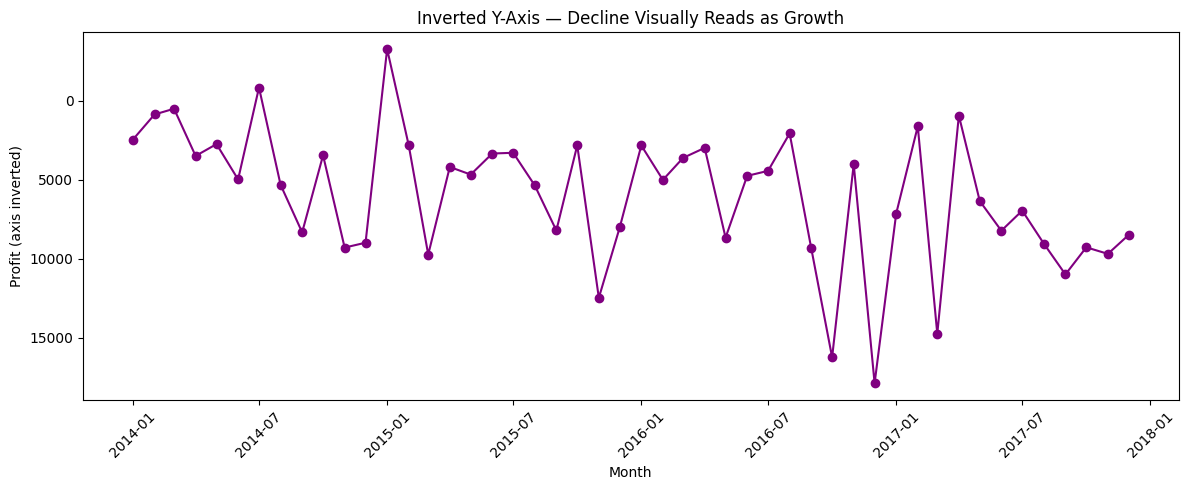

Distortion: flipping the y-axis direction makes a downward-trending profit line visually climb upward on the page, reversing the intuitive meaning of the slope for anyone not reading the axis labels carefully.


In [26]:
# =========================================================
# TASK 5d — Inverted y-axis on monthly profit
# =========================================================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_profit.index, monthly_profit.values, marker='o', color='purple')
ax.invert_yaxis()
ax.set_title('Inverted Y-Axis — Decline Visually Reads as Growth')
ax.set_xlabel('Month')
ax.set_ylabel('Profit (axis inverted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task5d_inverted_axis.png', dpi=150)
plt.show()

print("Distortion: flipping the y-axis direction makes a downward-trending "
      "profit line visually climb upward on the page, reversing the intuitive "
      "meaning of the slope for anyone not reading the axis labels carefully.")

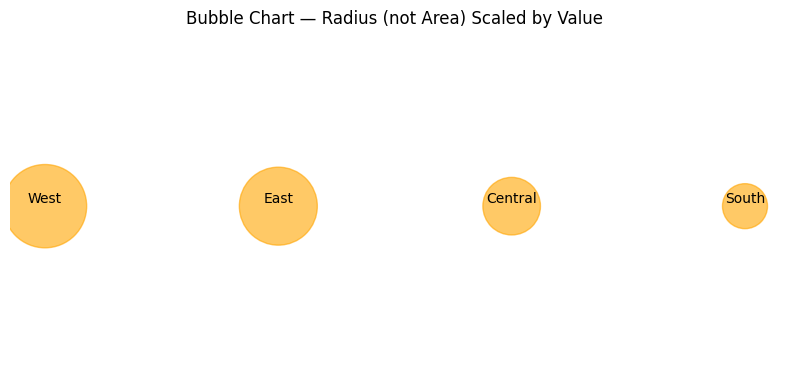

Distortion: circle radius is scaled linearly with the value, but the eye perceives circle *area* (~ radius^2), so a region with 2x the sales ends up visually appearing to have roughly 4x the size.


In [27]:
# =========================================================
# TASK 5e — Bubble chart where radius (not area) scales with value
# =========================================================
vals = region_sales.values
x = np.arange(len(region_sales))
radii = vals / vals.max() * 60          # radius scaled linearly (the flaw)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, [1] * len(x), s=radii**2, alpha=0.6, color='orange')  # area = pi*r^2
for i, name in enumerate(region_sales.index):
    ax.annotate(name, (x[i], 1), ha='center', va='bottom')
ax.set_title('Bubble Chart — Radius (not Area) Scaled by Value')
ax.axis('off')
plt.tight_layout()
plt.savefig('task5e_bubble_radius.png', dpi=150)
plt.show()

print("Distortion: circle radius is scaled linearly with the value, but the "
      "eye perceives circle *area* (~ radius^2), so a region with 2x the sales "
      "ends up visually appearing to have roughly 4x the size.")

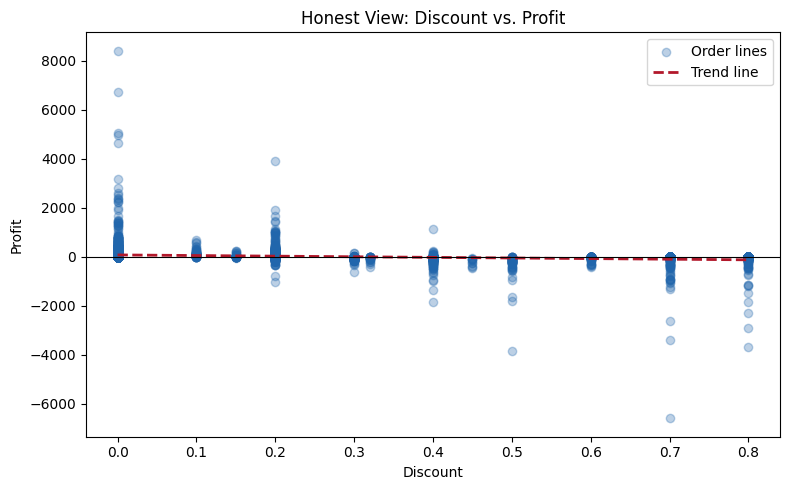

Trend slope: -249.05 profit per unit discount (negative relationship)


In [28]:
# =========================================================
# TASK 6a — Honest chart answering: "Is discounting hurting profit?"
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#2166AC', label='Order lines')

z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)
xs = np.linspace(df['Discount'].min(), df['Discount'].max(), 100)
ax.plot(xs, p(xs), color='#B2182B', linewidth=2, linestyle='--', label='Trend line')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
ax.set_title('Honest View: Discount vs. Profit')
ax.legend()
plt.tight_layout()
plt.savefig('task6a_honest.png', dpi=150)
plt.show()

print(f"Trend slope: {z[0]:.2f} profit per unit discount "
      f"({'negative' if z[0] < 0 else 'positive'} relationship)")

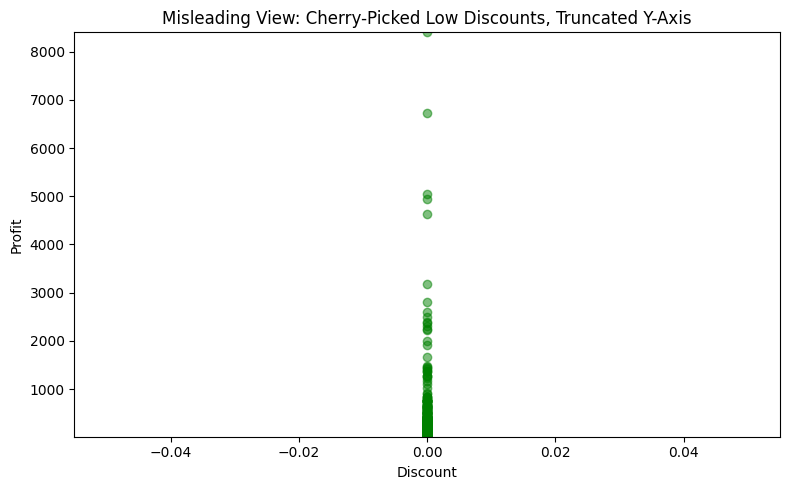

In [29]:
# =========================================================
# TASK 6b — Deliberately misleading version of the same question
# =========================================================
low_discount_only = df[df['Discount'] <= df['Discount'].quantile(0.4)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(low_discount_only['Discount'], low_discount_only['Profit'],
           color='green', alpha=0.5)
ax.set_ylim(low_discount_only['Profit'].quantile(0.4),
            low_discount_only['Profit'].max())
ax.set_title('Misleading View: Cherry-Picked Low Discounts, Truncated Y-Axis')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.savefig('task6b_misleading.png', dpi=150)
plt.show()

In [30]:
# =========================================================
# TASK 6c — Justification: chart type, color choice, accessibility check
# =========================================================
print("""
Question: Is discounting hurting profit?

Justification (honest chart):
- Chart type: scatter is correct because Discount and Profit are two continuous,
  unordered raw variables per order line — we need to see correlation shape and
  spread across the full dataset, not a single summary number.
- Color: only two colors are used (blue points, red trend line), both clearly
  distinguishable under colorblind simulation, and the chart does not rely on
  red/green loss-vs-gain coding anywhere.
- Accessibility: axis labels, a zero-baseline reference line, and a legend make
  the chart interpretable without depending on color alone; #2166AC and #B2182B
  against a white background both pass WCAG AA contrast (4.5:1) for text-sized
  elements, consistent with the Task 4 contrast checks.

Why the misleading version distorts:
- It cherry-picks only the bottom 40% of discount values, hiding the steeper
  losses that occur at higher discount levels.
- It truncates the y-axis to start near the 40th percentile of profit in that
  subset, compressing the visible range and making the remaining spread look
  tighter and more uniformly positive than the full data actually shows.

Conclusion: the honest chart shows a clear negative slope between discount and
profit, meaning discounting is in fact associated with declining profit — the
misleading version obscures this by restricting both axes and the data range.
""")


Question: Is discounting hurting profit?

Justification (honest chart):
- Chart type: scatter is correct because Discount and Profit are two continuous,
  unordered raw variables per order line — we need to see correlation shape and
  spread across the full dataset, not a single summary number.
- Color: only two colors are used (blue points, red trend line), both clearly
  distinguishable under colorblind simulation, and the chart does not rely on
  red/green loss-vs-gain coding anywhere.
- Accessibility: axis labels, a zero-baseline reference line, and a legend make
  the chart interpretable without depending on color alone; #2166AC and #B2182B
  against a white background both pass WCAG AA contrast (4.5:1) for text-sized
  elements, consistent with the Task 4 contrast checks.

Why the misleading version distorts:
- It cherry-picks only the bottom 40% of discount values, hiding the steeper
  losses that occur at higher discount levels.
- It truncates the y-axis to start near the 40th